# 0 - Helpers

In [8]:
from generate_time_comparison import *

# 1 - Retrieve networks

In [9]:
#years = [2025, 2030, 2035, 2040]
years = [2025, 2030]

# Main scenarios
scenarios_50 = ["baseline",
             "energy-match-50",
             "hourly-match-50-90",
             #"hourly-match-50-95",
             #"hourly-match-50-98",
             #"hourly-match-50-99",
             ]


scenarios_25 = ["baseline",
             "energy-match-25",
             "hourly-match-25-90",
             #"hourly-match-25-95",
             #"hourly-match-25-98",
             #"hourly-match-25-99",
             ]

# Load all networks
scenarios_all = {"main_CI_50": scenarios_50,
                 #"main_CI_25": scenarios_25,
                 }

df_networks_all = {}

for group, scenarios in scenarios_all.items():

    # Build MultiIndex
    index = pd.MultiIndex.from_product(
        [years, scenarios],
        names=["year", "scenario"]
    )

    # Create empty DataFrame
    df_networks = pd.DataFrame(index=index, columns=["network"])

    # Fill it
    for year, sc in index:
        try:
            n = pypsa.Network(f"../results/{sc}/networks/base_s_39___{year}.nc")
        except:
            print(f"{sc}-{year} not availabe")
            continue
        n = prepare_network(n)
        n.name = f"{sc}-{year}"
        df_networks.loc[(year, sc), "network"] = n

        m = strip_network_GoO(n)
        m.name = "GoO-" + m.name
        df_networks.loc[(year, sc), "GoO"] = m

    df_networks = df_networks.dropna()
    df_networks_all[group] = df_networks

# Calculate figsize automatically based on number of years
figsize_bar = get_figsize_from_years(years, FIGSIZE_BAR)
figsize_heatmap = get_figsize_from_years(years, FIGSIZE_HEATMAP_MAP)
figsize_arrow = FIGSIZE_ARROW  # Fixed size for arrow plot

print(f"Using figsize for bar plots: {figsize_bar}")
print(f"Using figsize for heatmap plots: {figsize_heatmap}")
print(f"Using figsize for arrow plot: {figsize_arrow}")


INFO:pypsa.network.io:New version 1.0.5 available! (Current: 1.0.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.0.5 available! (Current: 1.0.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.0.5 available! (Current: 1.0.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.0.5 available! (Current: 1.0.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.0.5 available! (Current:

Using figsize for bar plots: (6, 6)
Using figsize for heatmap plots: (8, 8)
Using figsize for arrow plot: (6, 6)


# 2 - GO market impacts

----------------------------------Processing main_CI_50 scenarios
------------------> Analysing result at system level


/home/user/OET/projects/google-go-vs-gc/google-go/notebooks/generate_time_comparison.py:386: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



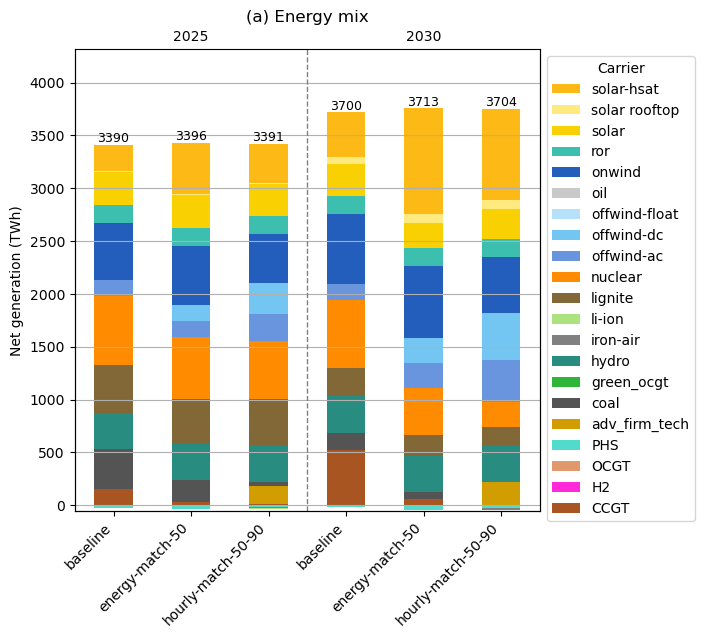

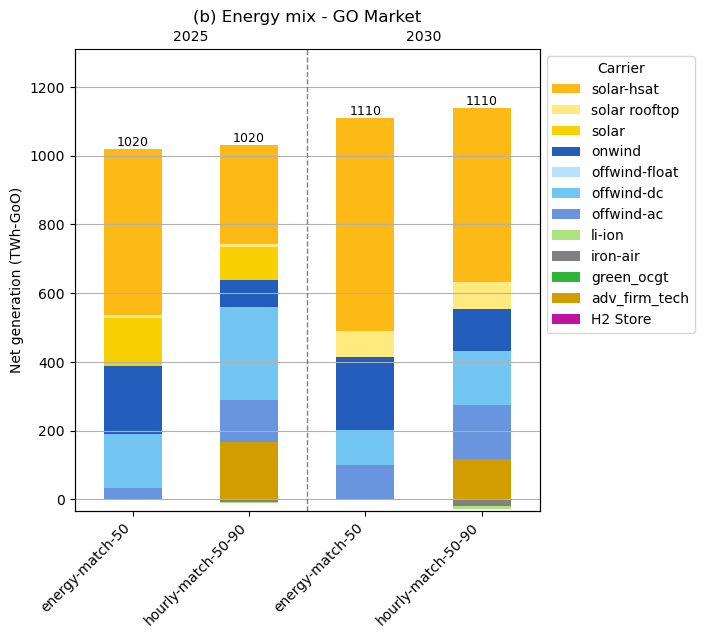

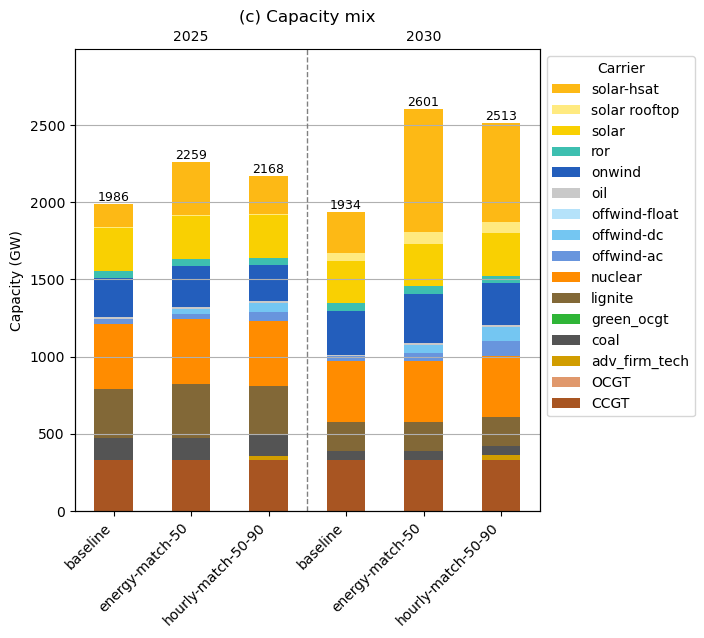

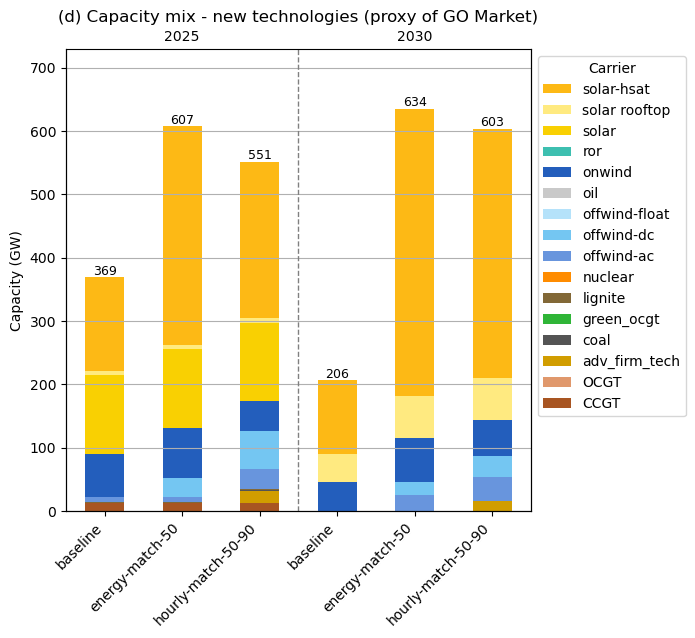

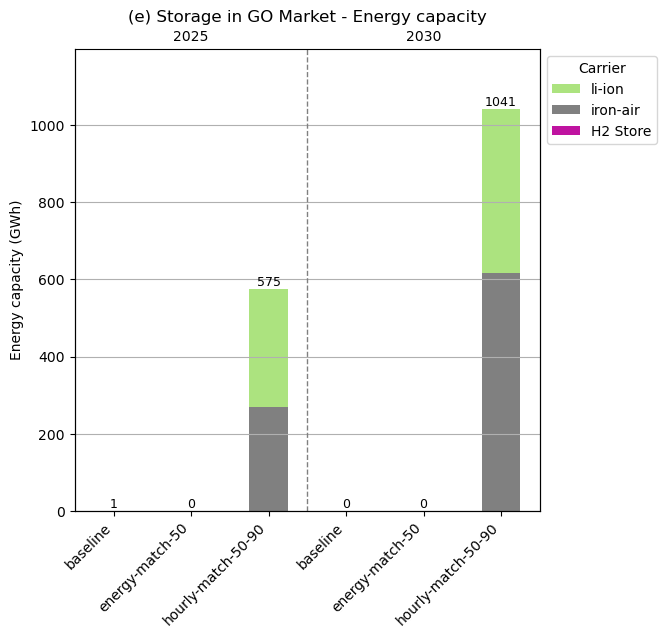

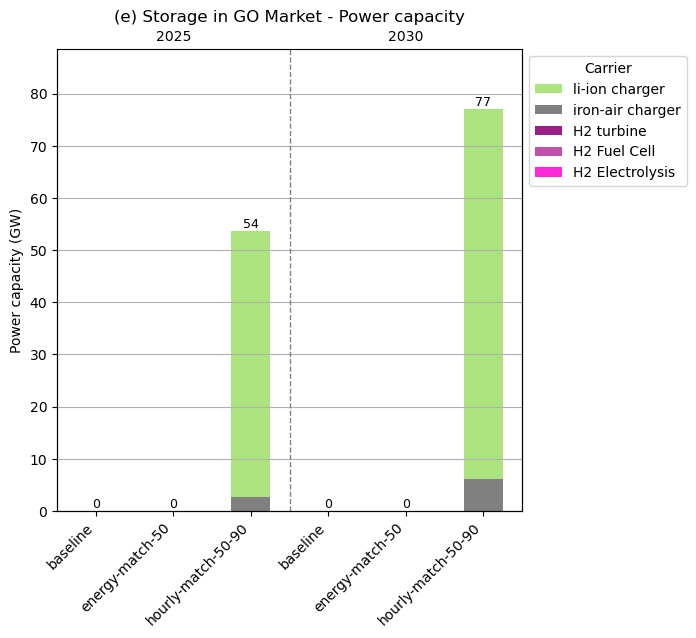

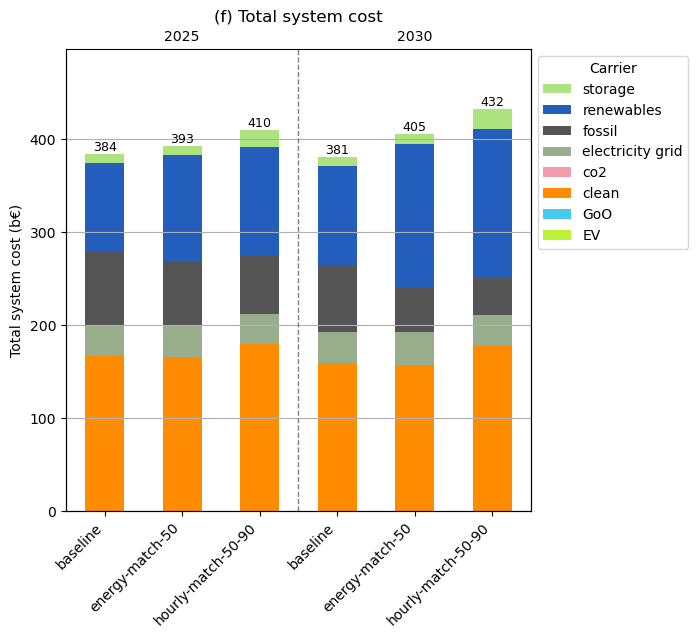

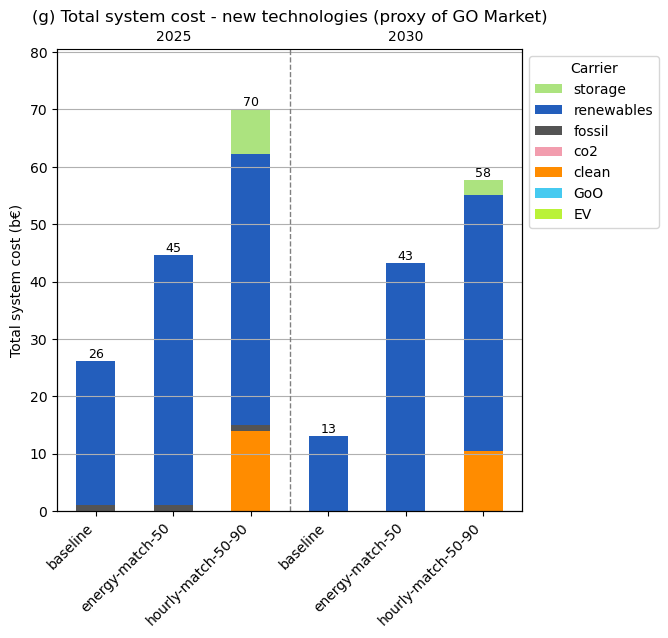

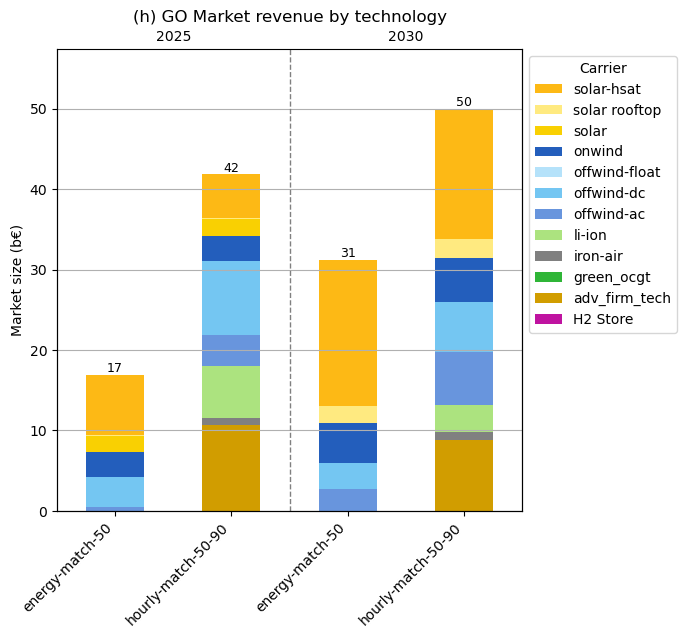

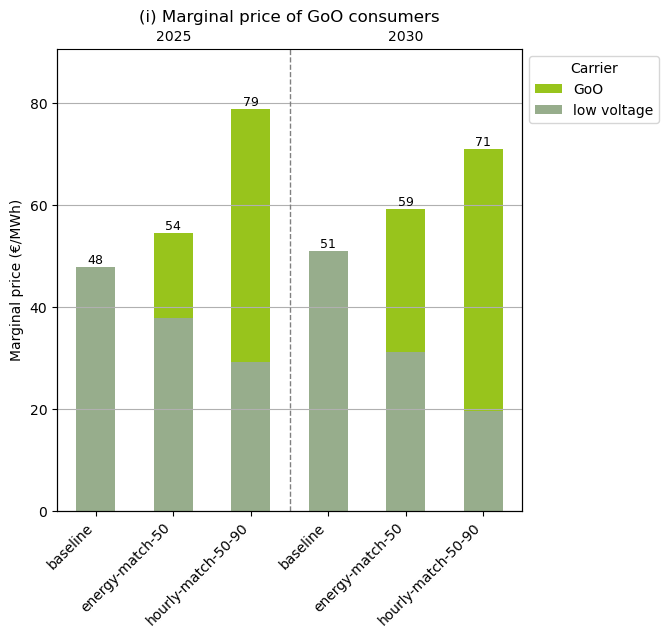

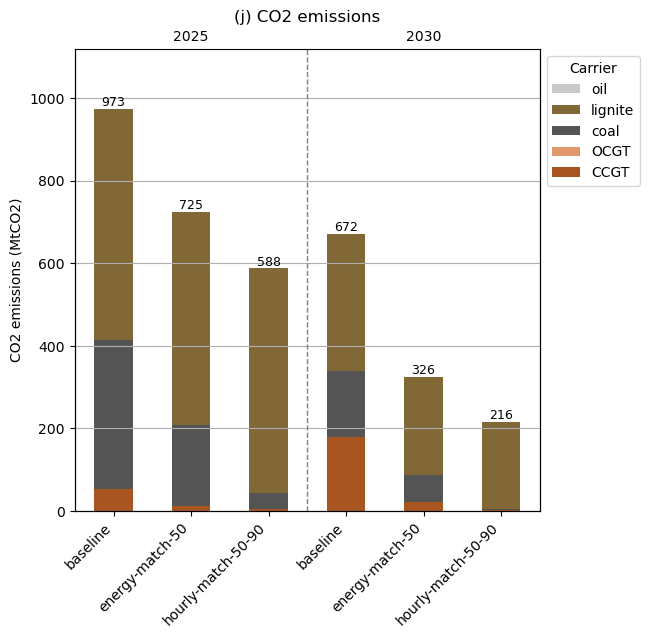

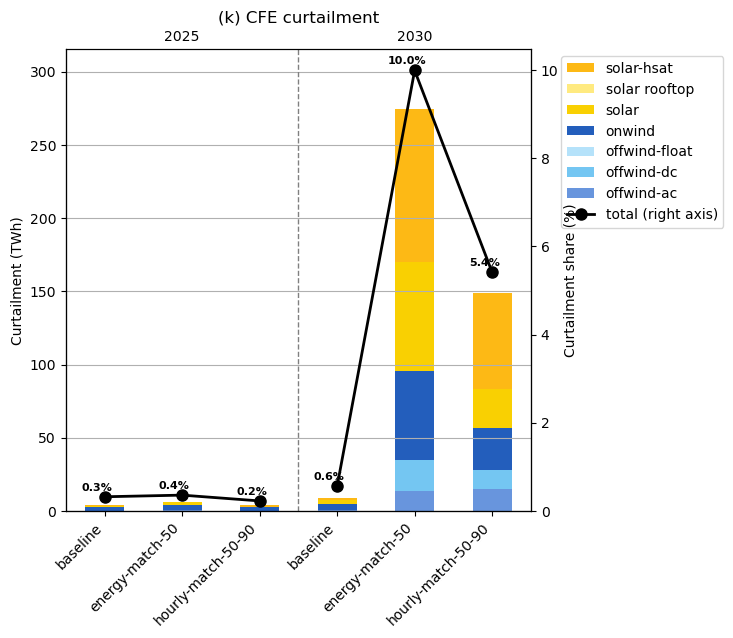

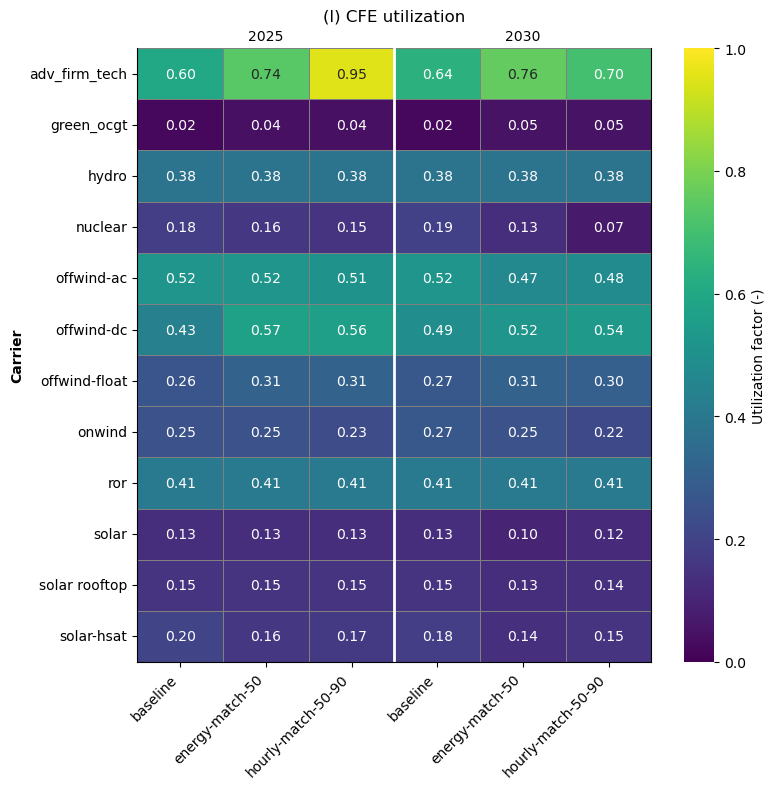

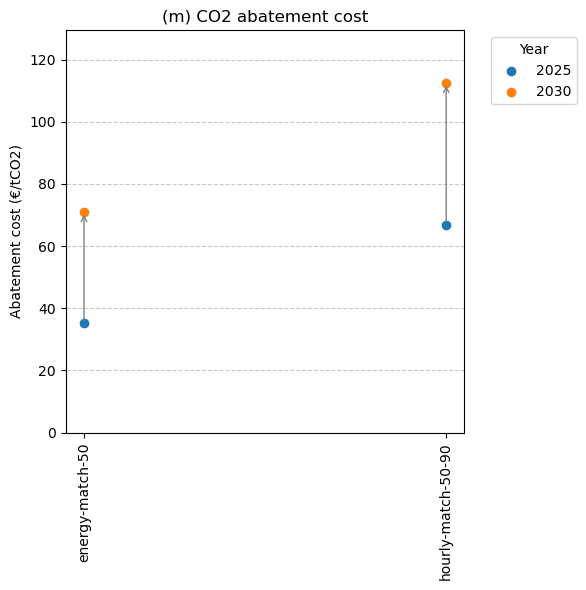

------------------> Analysing result at Germany level


/home/user/OET/projects/google-go-vs-gc/google-go/notebooks/generate_time_comparison.py:386: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



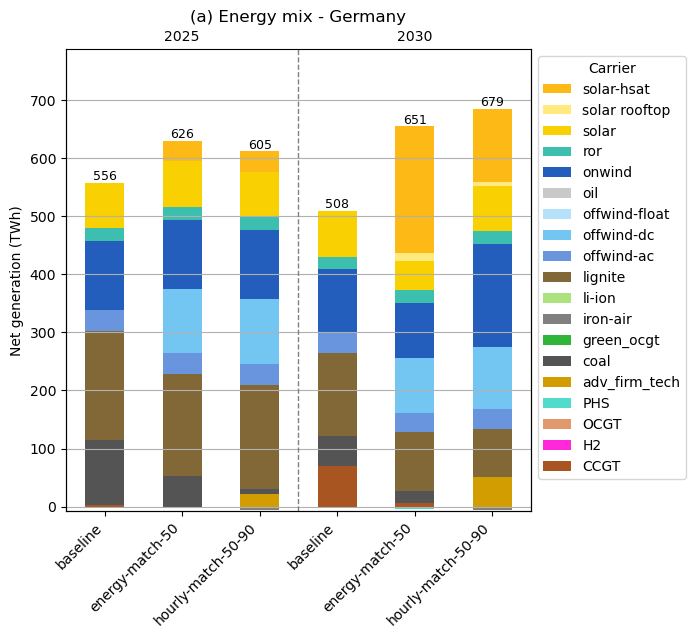

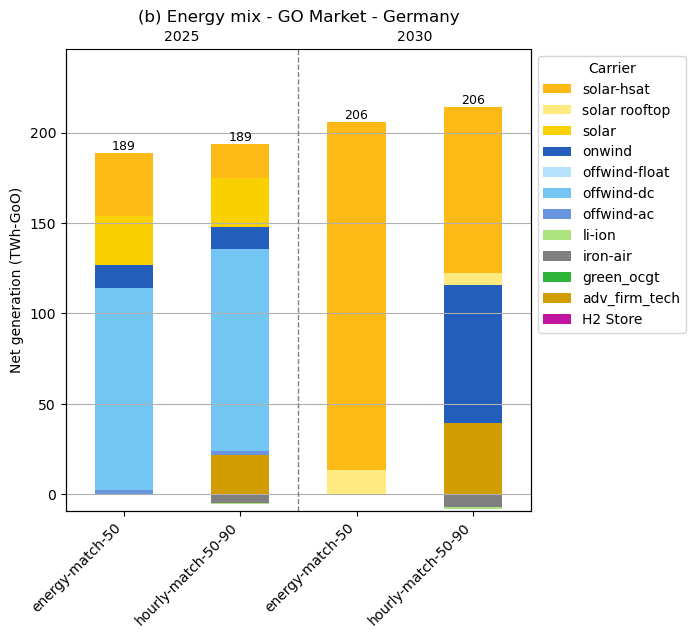

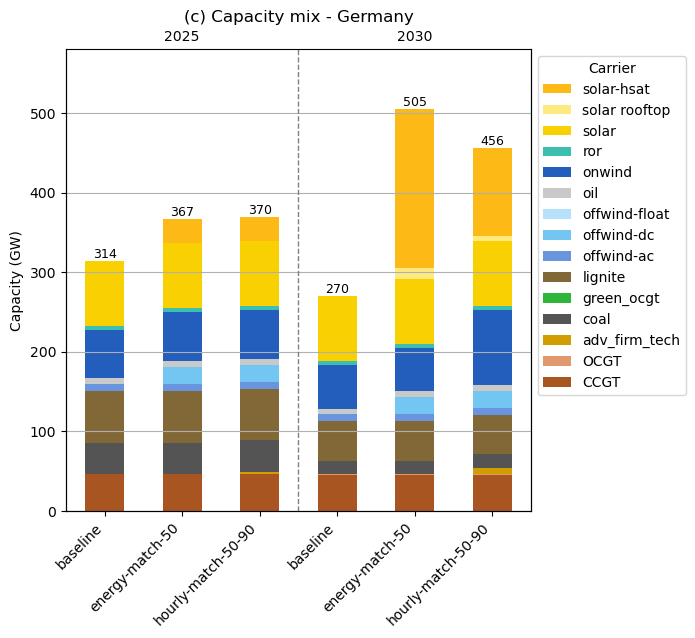

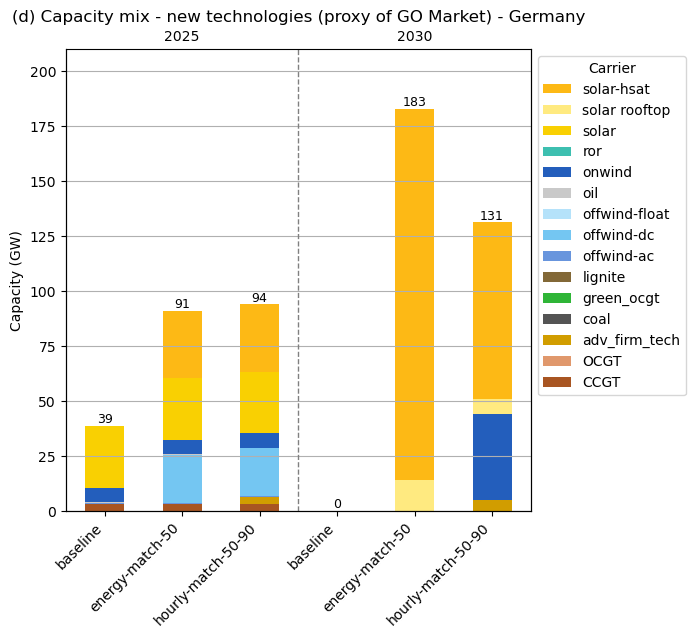

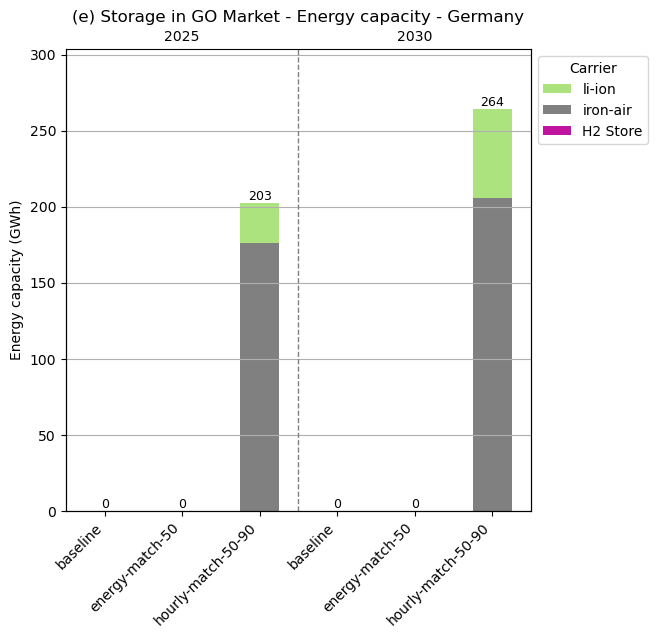

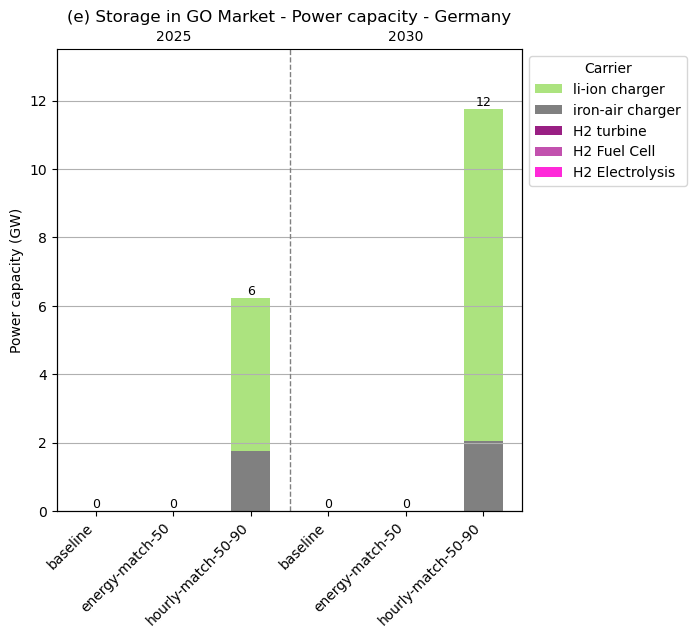

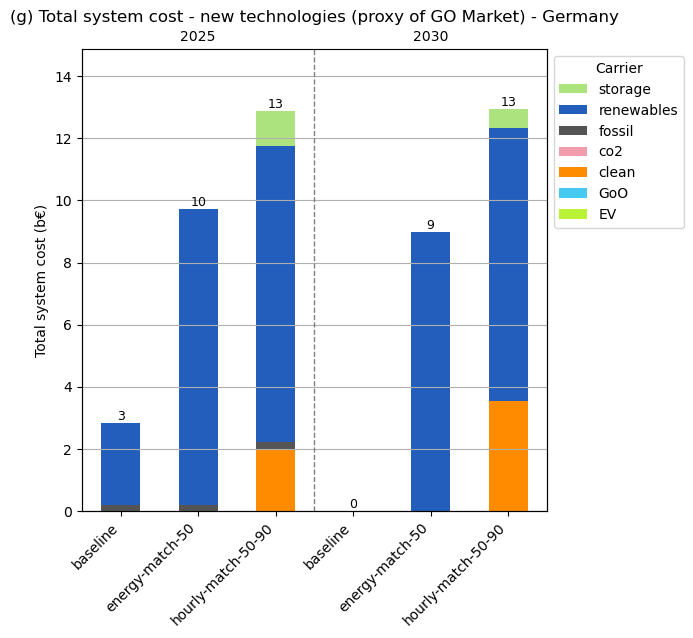

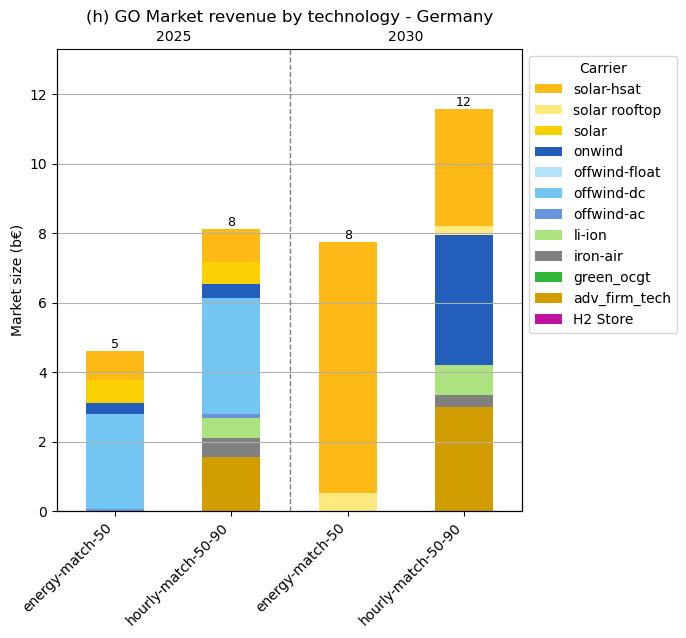

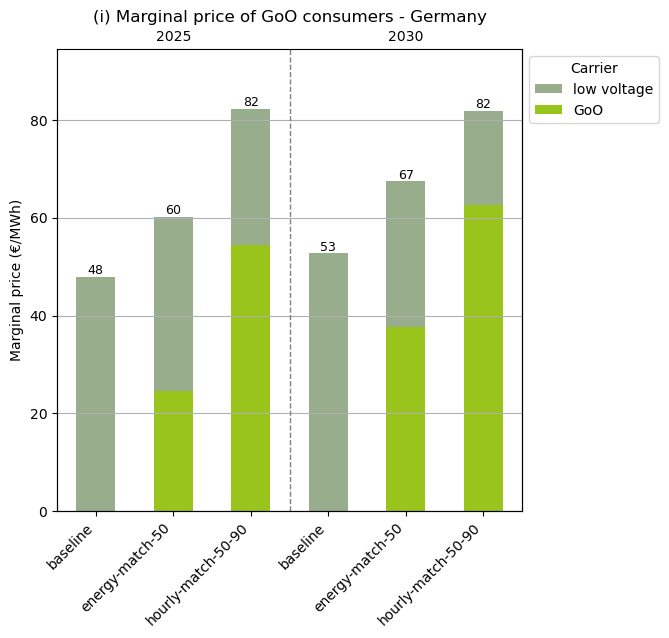

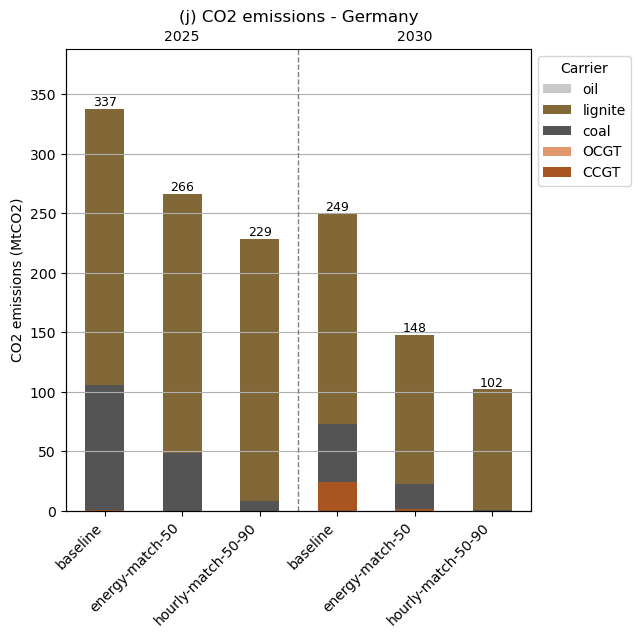

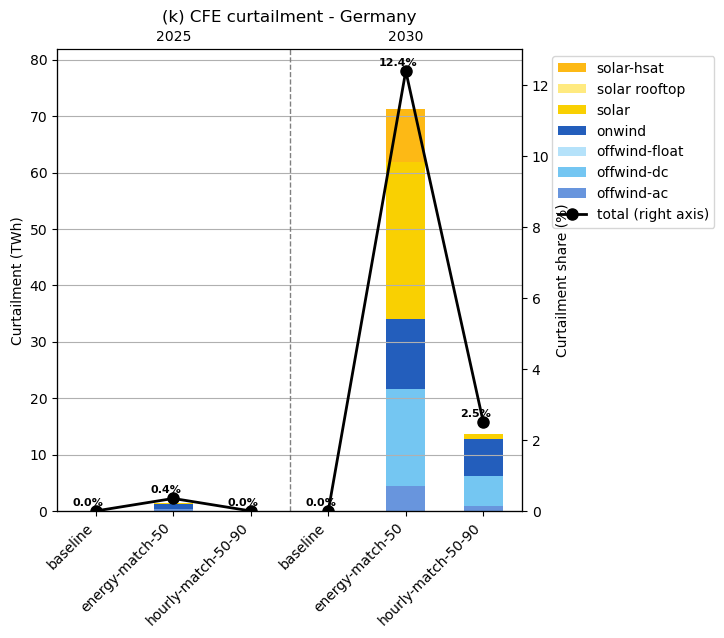

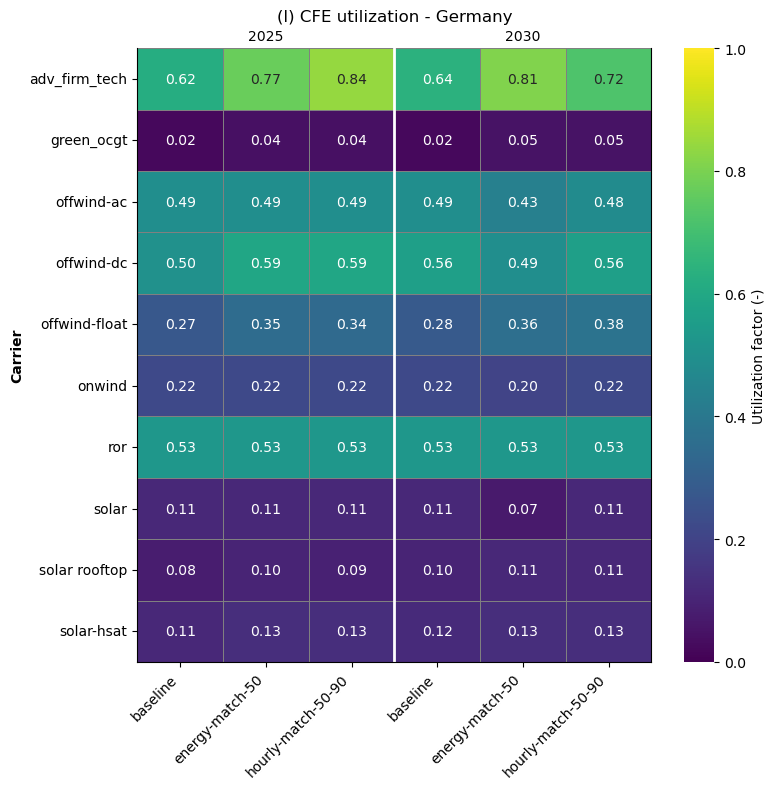

In [10]:
figures_to_generate = [
        'a', # derive_energy_mix
        'b', # derive_energy_mix_go
        'c', # derive_capacity_mix
        'd', # derive_capacity_mix_new
        'e1', # derive_storage_energy_capacity
        'e2', # derive_storage_power_capacity
        'f', # derive_total_system_cost
        'g', # derive_total_system_cost_new
        'h', # derive_go_market_revenue
        'i', # derive_marginal_price
        'j', # derive_co2_emissions
        'k', # derive_cfe_curtailment
        'l', # derive_cfe_utilization
        'm', # derive_co2_abatement_cost
]

# Figures for all groups of scenarios
fig_path_system = f"figures/time_comparison/system"
fig_path_countries = f"figures/time_comparison/countries"
countries = ["system",
             "DE",
             ]
for group, df_networks in df_networks_all.items():
    print(f"----------------------------------Processing {group} scenarios")
    
    for country in countries:
        scope = "system" if country == "system" else country_converter.CountryConverter().convert(country, to="short_name")
        fig_path = fig_path_system + f"-{group}" if country == "system" else fig_path_countries + f"-{country}-{group}"
        print(f"------------------> Analysing result at {scope} level")
        _, _ = derive_all_figures(df_networks, country=country,
                                  plot_fig=True, save_fig=True, fig_path=fig_path, save_csv=True, figures=figures_to_generate,
                                  figsize_bar=figsize_bar, figsize_heatmap=figsize_heatmap, figsize_arrow=figsize_arrow)
        plt.show()